# Digit Recognizer: A From-Scratch CNN

MNIST is a well known, trivially solved dataset, so this notebook is not chasing a leaderboard score. The goal is a compact, from-scratch convolutional network (no pretrained weights), trained and evaluated carefully, with attention to *what kind of mistakes* the model makes rather than just its final accuracy.

We will:

* Load and normalize the Kaggle Digit Recognizer CSVs.
* Train a small CNN (two convolutional blocks, dropout-regularized dense head) from scratch.
* Evaluate with a confusion matrix, not just accuracy.
* Compare a handful of correct predictions against misclassified ones, to see what the mistakes suggest about the model's limits.

## Imports

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
from torch.utils.data import DataLoader

from digitrecognizer.dataset import MNISTDataset, load_labeled_csv, train_val_split
from digitrecognizer.evaluate import (
    compute_confusion_matrix,
    correct_indices,
    misclassified_indices,
    predict,
)
from digitrecognizer.model import SmallCNN
from digitrecognizer.train import fit

sns.set_theme(style="whitegrid")
torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## Load and prepare data

The raw CSV holds one row per image: a `label` column plus 784 flattened pixel columns. We reshape each row back to a 28x28 image, normalize pixel values to `[0, 1]`, and split off a validation set. A simple random split is enough here — the dataset is large and balanced enough that stratification would not meaningfully change the validation set.

In [18]:
images, labels = load_labeled_csv("../data/raw/train.csv")
train_images, train_labels, val_images, val_labels = train_val_split(images, labels, val_fraction=0.1)

train_ds = MNISTDataset(train_images, train_labels)
val_ds = MNISTDataset(val_images, val_labels)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=256)

len(train_ds), len(val_ds)

(37800, 4200)

## Model

`SmallCNN` (`src/digitrecognizer/model.py`) is deliberately shallow: two conv -> ReLU -> max-pool blocks followed by a dropout-regularized dense head. MNIST digits are small, centered, and low-resolution, so there is little to gain from a deeper backbone; the interesting part of this exercise is training and evaluating it carefully, not the architecture itself.

In [19]:
model = SmallCNN(num_classes=10)
sum(p.numel() for p in model.parameters() if p.requires_grad)

421642

## Training

This dataset converges quickly, so a small number of epochs is enough.

In [20]:
history = fit(model, train_loader, val_loader, device=device, epochs=10, lr=1e-3)
history[-1]

{'epoch': 10,
 'train_loss': 0.020620517963666724,
 'val_loss': 0.0279271188515815,
 'val_accuracy': 0.991904761904762}

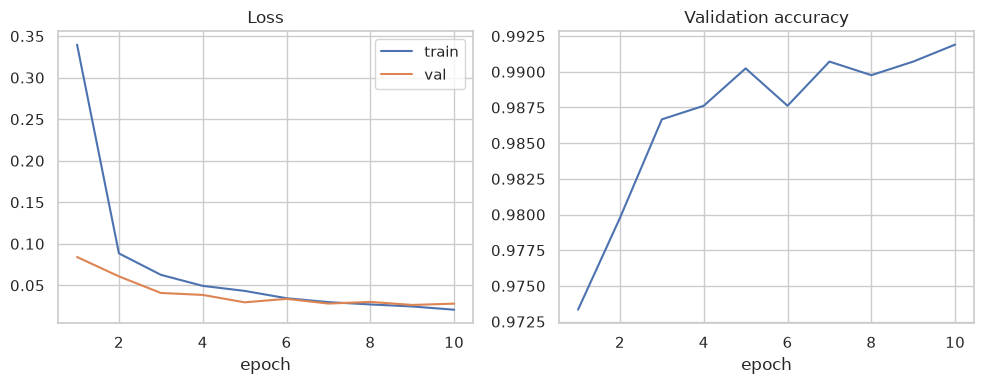

In [21]:
epochs = [h["epoch"] for h in history]
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(epochs, [h["train_loss"] for h in history], label="train")
axes[0].plot(epochs, [h["val_loss"] for h in history], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(epochs, [h["val_accuracy"] for h in history])
axes[1].set_title("Validation accuracy")
axes[1].set_xlabel("epoch")
fig.tight_layout()
fig.savefig("../outputs/figures/training_curves.png", dpi=150)

## Evaluation

Accuracy alone hides *which* digits get confused for which. A confusion matrix is cheap to compute and, even on an easy dataset like this, tends to surface genuinely informative pairs (4/9, 3/8, 7/1).

In [22]:
val_preds = predict(model, val_loader, device=device)
accuracy = (val_preds == val_labels).mean()
accuracy

np.float64(0.991904761904762)

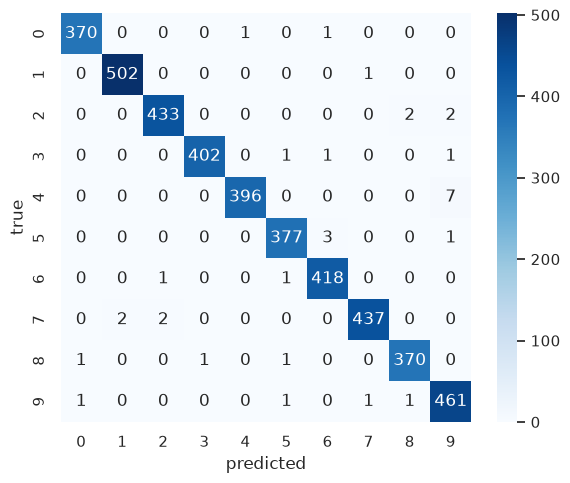

In [23]:
cm = compute_confusion_matrix(val_labels, val_preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_xlabel("predicted")
ax.set_ylabel("true")
fig.tight_layout()
fig.savefig("../outputs/figures/confusion_matrix.png", dpi=150)

## Correct predictions

A look at a handful of correctly classified digits, as a baseline of what "normal" model confidence looks like before comparing it against the mistakes in the next section.

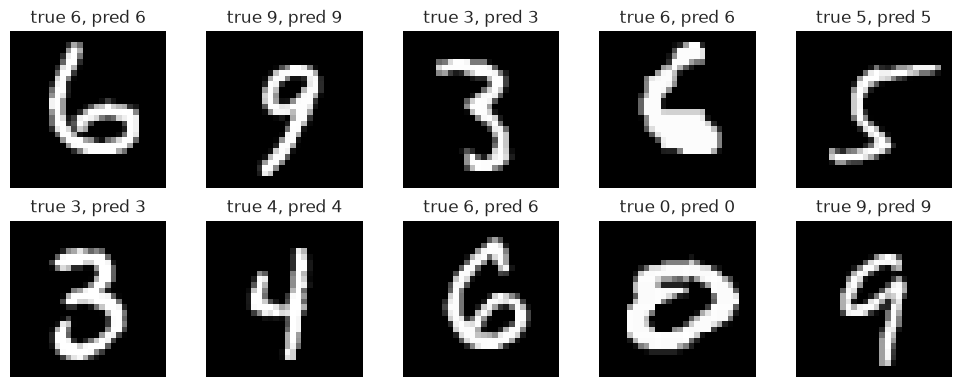

In [24]:
right = correct_indices(val_labels, val_preds)
sample = np.random.default_rng(0).choice(right, size=min(10, len(right)), replace=False)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for idx, ax in zip(sample, axes.ravel()):
    ax.imshow(val_images[idx], cmap="gray")
    ax.set_title(f"true {val_labels[idx]}, pred {val_preds[idx]}")
    ax.axis("off")
fig.tight_layout()
fig.savefig("../outputs/figures/correct_examples.png", dpi=150)

## Misclassified examples

A quick look at a handful of the model's mistakes, to see whether they are genuinely ambiguous digits or errors the model should not be making.

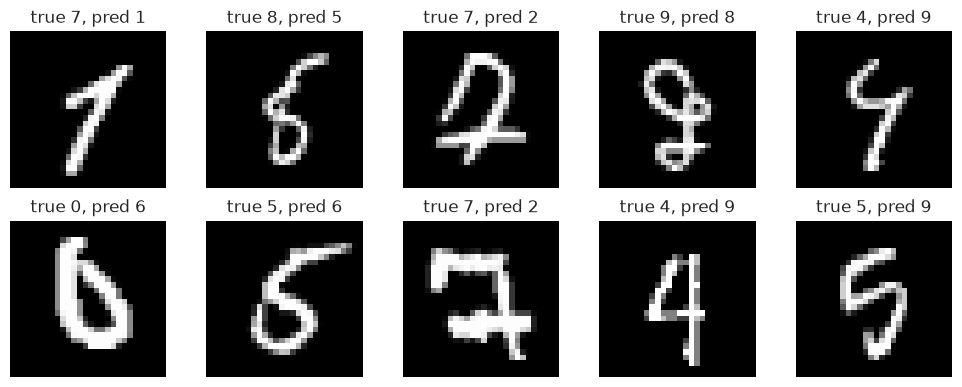

In [25]:
wrong = misclassified_indices(val_labels, val_preds)
sample = np.random.default_rng(0).choice(wrong, size=min(10, len(wrong)), replace=False)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for idx, ax in zip(sample, axes.ravel()):
    ax.imshow(val_images[idx], cmap="gray")
    ax.set_title(f"true {val_labels[idx]}, pred {val_preds[idx]}")
    ax.axis("off")
fig.tight_layout()
fig.savefig("../outputs/figures/misclassified_examples.png", dpi=150)

## Closing notes

A small from-scratch CNN reaches strong accuracy on MNIST quickly and with little tuning — the dataset is simple enough that this says more about MNIST than about the architecture. What it does demonstrate is a complete, careful pipeline: normalization, a from-scratch model, a real training loop, and evaluation that looks past the headline accuracy number to the specific digits the model still confuses.